In [1]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Device:", device)

Device: cuda


## Warm-up — CartPole Environment

Before training an agent, I inspect the CartPole-v1 environment and run one random-action episode. This gives a baseline reward that a learning agent should beat.

In [2]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=42)

print("Initial observation:", obs)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


In [3]:
obs, _ = env.reset(seed=42)

total_reward = 0
done = False

while not done:
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    
    total_reward += reward
    done = terminated or truncated
    obs = next_obs

print("Random agent total reward:", total_reward)

Random agent total reward: 25.0


## Replay Buffer

The replay buffer stores the agent's past experiences as `(state, action, reward, next_state, done)` tuples. During training, random mini-batches are sampled from this buffer, which makes learning more stable than training only on consecutive transitions.

In [4]:
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = np.array(states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int64)
        rewards = np.array(rewards, dtype=np.float32)
        next_states = np.array(next_states, dtype=np.float32)
        dones = np.array(dones, dtype=np.float32)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

## Q-Network

The Q-network takes the current CartPole state as input and outputs one Q-value for each possible action. Since CartPole has 4 observation values and 2 actions, the network maps a 4-dimensional state to 2 Q-values.

In [5]:
env = gym.make("CartPole-v1")

n_obs = env.observation_space.shape[0]
n_actions = env.action_space.n

print("Observation dimension:", n_obs)
print("Number of actions:", n_actions)

Observation dimension: 4
Number of actions: 2


In [6]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

In [7]:
q_net = QNetwork(n_obs, n_actions).to(device)
target_net = QNetwork(n_obs, n_actions).to(device)

target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

buffer = ReplayBuffer(capacity=50_000)

gamma = 0.99
batch_size = 64
min_buffer_size = 1000
target_sync_every = 1000
total_steps = 30_000

epsilon_start = 1.0
epsilon_final = 0.05
epsilon_decay_steps = 5000

In [8]:
def get_epsilon(step):
    if step >= epsilon_decay_steps:
        return epsilon_final
    
    fraction = step / epsilon_decay_steps
    epsilon = epsilon_start + fraction * (epsilon_final - epsilon_start)
    return epsilon

In [9]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        q_values = q_net(state_tensor)
    
    return q_values.argmax(dim=1).item()

In [10]:
def dqn_train_step():
    states, actions, rewards, next_states, dones = buffer.sample(batch_size)
    
    states = torch.tensor(states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions, dtype=torch.long).to(device)
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    dones = torch.tensor(dones, dtype=torch.float32).to(device)
    
    q_values = q_net(states)
    q_values_for_actions = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    with torch.no_grad():
        next_q_values = target_net(next_states)
        max_next_q_values = next_q_values.max(dim=1).values
        
        targets = rewards + gamma * (1 - dones) * max_next_q_values
    
    loss = nn.functional.mse_loss(q_values_for_actions, targets)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

## DQN Training Loop

The agent interacts with the environment for 30,000 steps. At each step it selects an action using epsilon-greedy exploration, stores the transition in the replay buffer, and after the buffer has enough samples, performs one gradient update from a random mini-batch.

In [11]:
episode_rewards = []
losses = []

state, _ = env.reset(seed=42)
episode_reward = 0

start_time = time.perf_counter()

for step in range(1, total_steps + 1):
    epsilon = get_epsilon(step)
    
    action = select_action(state, epsilon)
    
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    
    buffer.push(state, action, reward, next_state, done)
    
    state = next_state
    episode_reward += reward
    
    if len(buffer) >= min_buffer_size:
        loss = dqn_train_step()
        losses.append(loss)
    
    if step % target_sync_every == 0:
        target_net.load_state_dict(q_net.state_dict())
    
    if done:
        episode_rewards.append(episode_reward)
        state, _ = env.reset()
        episode_reward = 0
    
    if step % 5000 == 0:
        recent_avg = np.mean(episode_rewards[-20:]) if len(episode_rewards) >= 20 else np.mean(episode_rewards)
        print(
            f"Step {step}/{total_steps} | "
            f"Epsilon: {epsilon:.3f} | "
            f"Episodes: {len(episode_rewards)} | "
            f"Recent avg reward: {recent_avg:.1f}"
        )

dqn_train_time = time.perf_counter() - start_time

print("DQN training time:", round(dqn_train_time, 2), "seconds")
print("Number of episodes:", len(episode_rewards))

Step 5000/30000 | Epsilon: 0.050 | Episodes: 220 | Recent avg reward: 54.8
Step 10000/30000 | Epsilon: 0.050 | Episodes: 253 | Recent avg reward: 158.1
Step 15000/30000 | Epsilon: 0.050 | Episodes: 279 | Recent avg reward: 168.7
Step 20000/30000 | Epsilon: 0.050 | Episodes: 307 | Recent avg reward: 169.3
Step 25000/30000 | Epsilon: 0.050 | Episodes: 343 | Recent avg reward: 151.4
Step 30000/30000 | Epsilon: 0.050 | Episodes: 374 | Recent avg reward: 183.0
DQN training time: 67.35 seconds
Number of episodes: 374


In [12]:
def moving_average(values, window=100):
    if len(values) < window:
        return np.array([])
    
    return np.convolve(values, np.ones(window) / window, mode="valid")

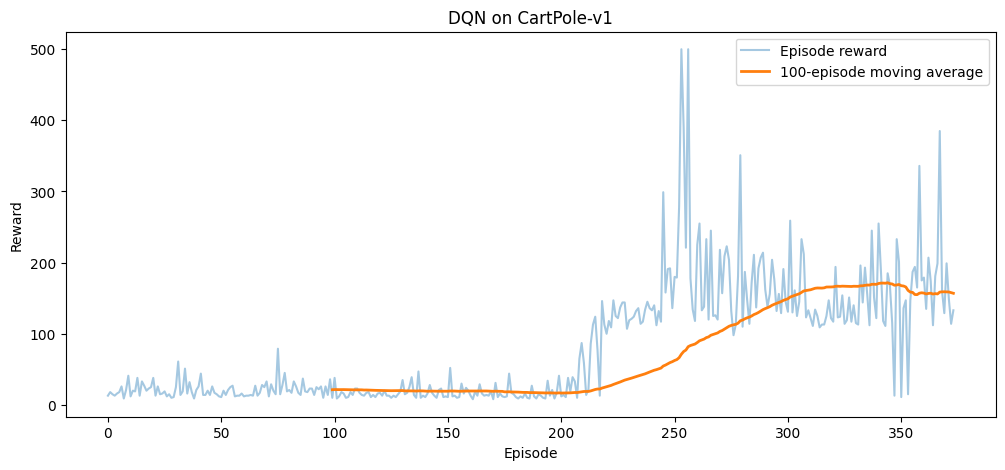

In [13]:
rewards_ma100 = moving_average(episode_rewards, window=100)

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, label="Episode reward", alpha=0.4)

if len(rewards_ma100) > 0:
    plt.plot(
        range(99, 99 + len(rewards_ma100)),
        rewards_ma100,
        label="100-episode moving average",
        linewidth=2
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on CartPole-v1")
plt.legend()
plt.show()

In [14]:
dqn_last_100_avg = np.mean(episode_rewards[-100:])

print(f"DQN average reward over last 100 episodes: {dqn_last_100_avg:.2f}")

DQN average reward over last 100 episodes: 156.91


## DQN Results Interpretation

The DQN agent was trained from scratch on CartPole-v1 for **30,000 environment steps** using a replay buffer, a target network, and epsilon-greedy exploration.

At the beginning of training, the agent mostly selected random actions because epsilon was high. As epsilon decayed to **0.05**, the agent increasingly relied on the Q-values predicted by the trained network.

The reward curve shows that the agent did learn better behavior over time. Early episode rewards were low, while later episodes often reached much higher rewards, sometimes above 300 and even close to the 500 maximum.

However, the training was still unstable. The reward curve remained noisy, and the final 100-episode moving average was only **156.91**, which is below the CartPole-v1 solved threshold of around 475 average reward.

Overall, the DQN improved compared to a random policy, but it did not fully solve the environment within 30,000 steps. More stable training could require tuning epsilon decay, target-network sync frequency, learning rate, or training for more environment steps.

In [15]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

In [16]:
def moving_average(values, window=100):
    if len(values) < window:
        return np.array([])
    
    return np.convolve(values, np.ones(window) / window, mode="valid")

# PPO with Stable-Baselines3

I train PPO agents using Stable-Baselines3.

First, I train PPO on CartPole-v1, the same environment used for the DQN agent. Unlike the DQN implementation from scratch, PPO is trained using a well-tested library implementation.

In [18]:
cartpole_env = Monitor(gym.make("CartPole-v1"))

ppo_cartpole = PPO(
    "MlpPolicy",
    cartpole_env,
    verbose=0,
    seed=42
)

t0 = time.perf_counter()

ppo_cartpole.learn(total_timesteps=50_000)

cartpole_train_time = time.perf_counter() - t0

mean_reward_cartpole, std_reward_cartpole = evaluate_policy(
    ppo_cartpole,
    cartpole_env,
    n_eval_episodes=20
)

print(
    f"PPO CartPole: {mean_reward_cartpole:.1f} ± {std_reward_cartpole:.1f} "
    f"over 20 episodes (trained in {cartpole_train_time:.0f}s)"
)

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 107s)


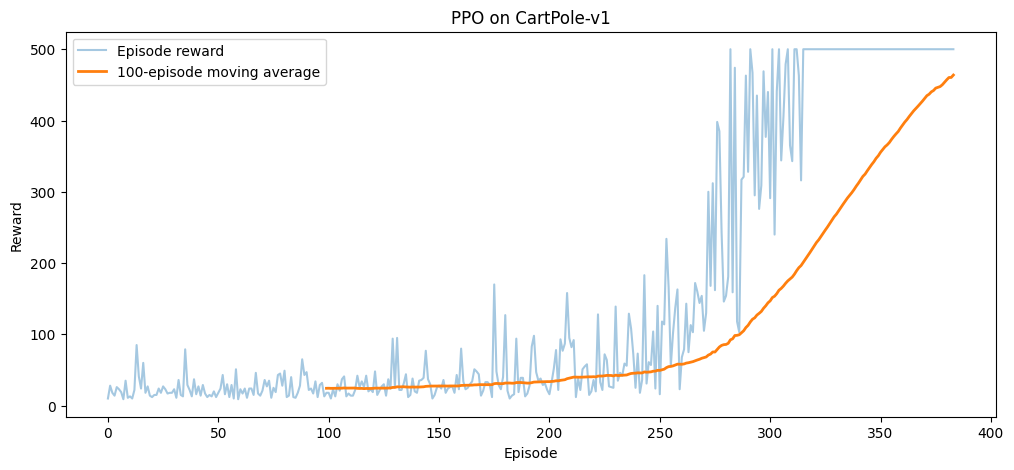

PPO CartPole average reward over last 100 episodes: 463.78
Number of CartPole episodes: 384


In [19]:
cartpole_rewards = cartpole_env.get_episode_rewards()

cartpole_rewards_ma100 = moving_average(cartpole_rewards, window=100)

plt.figure(figsize=(12, 5))
plt.plot(cartpole_rewards, label="Episode reward", alpha=0.4)

if len(cartpole_rewards_ma100) > 0:
    plt.plot(
        range(99, 99 + len(cartpole_rewards_ma100)),
        cartpole_rewards_ma100,
        label="100-episode moving average",
        linewidth=2
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO on CartPole-v1")
plt.legend()
plt.show()

ppo_cartpole_last_100_avg = np.mean(cartpole_rewards[-100:])

print(f"PPO CartPole average reward over last 100 episodes: {ppo_cartpole_last_100_avg:.2f}")
print(f"Number of CartPole episodes: {len(cartpole_rewards)}")

## PPO CartPole Results Interpretation

The PPO agent successfully solved CartPole-v1. During evaluation, it achieved a mean reward of **500.0 ± 0.0** over 20 episodes, meaning it reached the maximum possible reward in every evaluation episode.

The training reward curve also shows clear learning progress. Early rewards were low and unstable, but the 100-episode moving average increased steadily and reached **463.78** over the last 100 training episodes.

Compared with the DQN agent, PPO produced a much stronger and more stable policy on CartPole. Although PPO took longer to train in wall-clock time (**107 seconds**), it reached near-perfect performance, while the DQN agent remained much less stable.

## PPO on LunarLander-v3

Next, I train PPO on LunarLander-3. This environment is harder than CartPole because the agent must control a lander and safely land it on a target pad. The reward structure is more complex, and learning usually requires many more timesteps.
Although the lab text mentions `LunarLander-v2`, my installed Gymnasium version uses `LunarLander-v3`, so I trained PPO on `LunarLander-v3` instead. The environment serves the same purpose in this lab: testing PPO on a harder control task than CartPole.

In [22]:
!pip install swig

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 5.3 MB/s eta 0:00:01
   ------------------------------------- -- 2.4/2.5 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 4.8 MB/s  0:00:00



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
!pip install "gymnasium[box2d]"


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
lunar_env = Monitor(gym.make("LunarLander-v3"))

ppo_lunar = PPO(
    "MlpPolicy",
    lunar_env,
    verbose=0,
    seed=42
)

t0 = time.perf_counter()

ppo_lunar.learn(total_timesteps=300_000)

lunar_train_time = time.perf_counter() - t0

mean_reward_lunar, std_reward_lunar = evaluate_policy(
    ppo_lunar,
    lunar_env,
    n_eval_episodes=20
)

print(
    f"PPO LunarLander: {mean_reward_lunar:.1f} ± {std_reward_lunar:.1f} "
    f"over 20 episodes (trained in {lunar_train_time:.0f}s)"
)

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(

PPO LunarLander: 109.8 ± 108.1 over 20 episodes (trained in 635s)


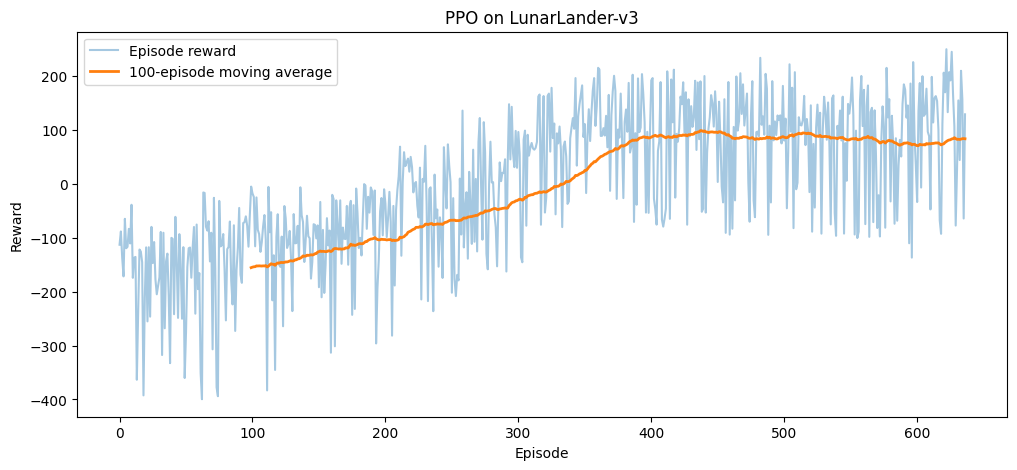

PPO LunarLander average reward over last 100 episodes: 83.12
Number of LunarLander episodes: 637


In [28]:
lunar_rewards = lunar_env.get_episode_rewards()

lunar_rewards_ma100 = moving_average(lunar_rewards, window=100)

plt.figure(figsize=(12, 5))
plt.plot(lunar_rewards, label="Episode reward", alpha=0.4)

if len(lunar_rewards_ma100) > 0:
    plt.plot(
        range(99, 99 + len(lunar_rewards_ma100)),
        lunar_rewards_ma100,
        label="100-episode moving average",
        linewidth=2
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO on LunarLander-v3")
plt.legend()
plt.show()

ppo_lunar_last_100_avg = np.mean(lunar_rewards[-100:])

print(f"PPO LunarLander average reward over last 100 episodes: {ppo_lunar_last_100_avg:.2f}")
print(f"Number of LunarLander episodes: {len(lunar_rewards)}")

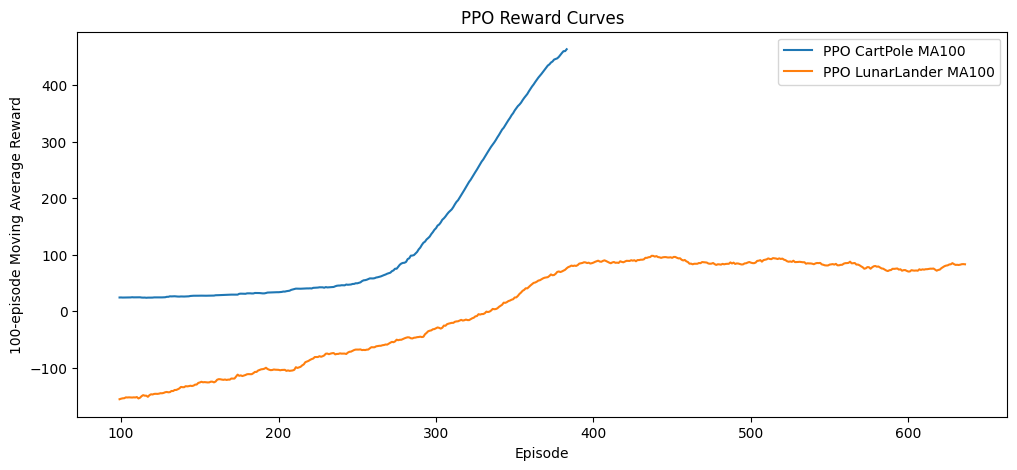

In [29]:
plt.figure(figsize=(12, 5))

if len(cartpole_rewards_ma100) > 0:
    plt.plot(
        range(99, 99 + len(cartpole_rewards_ma100)),
        cartpole_rewards_ma100,
        label="PPO CartPole MA100"
    )

if len(lunar_rewards_ma100) > 0:
    plt.plot(
        range(99, 99 + len(lunar_rewards_ma100)),
        lunar_rewards_ma100,
        label="PPO LunarLander MA100"
    )

plt.xlabel("Episode")
plt.ylabel("100-episode Moving Average Reward")
plt.title("PPO Reward Curves")
plt.legend()
plt.show()

## PPO LunarLander Results Interpretation

The PPO agent improved significantly on LunarLander-v3 during training. At the beginning, episode rewards were mostly negative, showing that the agent often crashed or failed to land successfully.

Over time, the 100-episode moving average increased steadily and became positive, meaning the agent learned useful landing behavior. However, the final evaluation result was **109.8 ± 108.1** over 20 episodes, which shows that performance was still unstable.

The large standard deviation indicates that the agent sometimes performed well but still had many inconsistent episodes. Unlike CartPole, LunarLander was not fully solved, since the usual solved threshold is around **200 average reward**.

Overall, PPO learned meaningful behavior on LunarLander-v3, but it would likely need more timesteps, better hyperparameters, or additional tuning to reach a stable solved performance.

## PPO Reward Curve Comparison

The PPO reward curves show a clear difference between CartPole-v1 and LunarLander-v3. CartPole was solved much more quickly, with the moving average rising close to the maximum reward of 500.

LunarLander-v3 improved more slowly and remained much noisier. This reflects the higher difficulty of the environment, where the agent must learn more complex control behavior such as managing velocity, angle, fuel usage, and landing position.

Overall, PPO handled both environments, but CartPole was much easier to solve, while LunarLander required substantially more training and still did not reach a stable solved reward in this run.

## Comparison and Reflection

In [31]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Agent": [
        "DQN (from scratch)",
        "PPO (SB3)",
        "PPO (SB3)"
    ],
    "Environment": [
        "CartPole-v1",
        "CartPole-v1",
        "LunarLander-v3"
    ],
    "Wall-clock training time (s)": [
        dqn_train_time,
        cartpole_train_time,
        lunar_train_time
    ],
    "Avg reward (last 100 episodes)": [
        dqn_last_100_avg,
        ppo_cartpole_last_100_avg,
        ppo_lunar_last_100_avg
    ]
})

comparison_df

,Agent,Environment,Wall-clock training time (s),Avg reward (last 100 episodes)
0,DQN (from scratch),CartPole-v1,67.346218,156.910000
1,PPO (SB3),CartPole-v1,107.428226,463.780000
2,PPO (SB3),LunarLander-v3,634.747816,83.119217


## Comparison and Reflection

The comparison shows that PPO performed much better than the DQN implementation on CartPole-v1. The DQN agent trained faster in wall-clock time, taking about **67.35 seconds**, while PPO took about **107.43 seconds**. However, DQN did not solve CartPole, reaching only **156.91** average reward over the last 100 episodes. PPO, on the other hand, reached **463.78** average reward over the last 100 episodes and achieved **500.0 ± 0.0** during evaluation, so PPO was clearly more successful in terms of environment performance. In terms of environment steps, PPO also reached a stronger result within **50,000 timesteps**, while my DQN did not fully solve the environment within **30,000 steps**, likely because the scratch DQN is more sensitive to replay buffer behavior, target-network syncing, epsilon decay, and hyperparameter choices.

I would not expect the same basic DQN code to perform similarly well on LunarLander-v3 without major improvements. LunarLander is much harder than CartPole because the agent must control thrust, angle, velocity, and landing position while dealing with a more complex reward signal. A basic DQN could struggle with unstable Q-value estimates, poor exploration, and overestimation bias. The first improvement I would try is **Double DQN**, because it reduces Q-value overestimation by separating action selection from target evaluation. After that, I would consider Dueling DQN or Prioritized Experience Replay to improve value estimation and learn more efficiently from important transitions.

For a real project, I would usually use a library like Stable-Baselines3 instead of rolling my own RL algorithm from scratch. Implementing DQN manually is very useful for learning how replay buffers, target networks, epsilon-greedy exploration, and Bellman targets work. However, small implementation or hyperparameter mistakes can make training unstable, as seen in the DQN result. Stable-Baselines3 provides reliable implementations, logging tools, evaluation utilities, and stronger defaults, which makes it more practical for real experimentation. I would only implement an RL algorithm from scratch if my goal was research, debugging a specific idea, or learning the algorithm deeply.

Note: The lab refers to LunarLander-v2, but my installed Gymnasium version uses LunarLander-v3, so I used LunarLander-v3 for the PPO experiment.